# Notebook 03 — Exploratory Data Analysis (EDA)
This notebook combines two HR datasets (IBM HR and Employee Attrition Data) by standardizing their schemas and merging them into a unified dataset. The combined HR data is then joined with external LinkedIn data via job title. Additionally, exploratory data analysis (EDA) is conducted on the merged dataset to uncover key patterns and assess data quality, including summary statistics, distribution analysis, and visualizations of important variables such as attrition, income, tenure, and job characteristics.

### Load data into Pandas dataframe

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
bucket = "ads508-team-4-private"

ibm_path = f"s3://{bucket}/raw/ibm_hr.csv"
attrition_path = f"s3://{bucket}/raw/employee_attrition_data.csv"
job_postings = f"s3://{bucket}/raw/job_postings.csv"

print(ibm_path)
print(attrition_path)
print(job_postings)

s3://ads508-team-4-private/raw/ibm_hr.csv
s3://ads508-team-4-private/raw/employee_attrition_data.csv
s3://ads508-team-4-private/raw/job_postings.csv


In [5]:
df_ibm = pd.read_csv(ibm_path)
df_attrition = pd.read_csv(attrition_path)
df_job_postings = pd.read_csv(job_postings)

In [6]:
df_ibm.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [13]:
print(df_ibm.shape)

(1470, 35)


In [14]:
df_attrition.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [15]:
print(df_attrition.shape)

(10000, 26)


### Standardize columns and concatenate files

In [7]:
# Rename df_attrition columns to match df_ibm where possible
df_attrition_renamed = df_attrition.rename(columns={
    "Employee_ID": "EmployeeNumber",
    "Age": "Age",
    "Gender": "Gender",
    "Marital_Status": "MaritalStatus",
    "Department": "Department",
    "Job_Role": "JobRole",
    "Job_Level": "JobLevel",
    "Monthly_Income": "MonthlyIncome",
    "Hourly_Rate": "HourlyRate",
    "Years_at_Company": "YearsAtCompany",
    "Years_in_Current_Role": "YearsInCurrentRole",
    "Years_Since_Last_Promotion": "YearsSinceLastPromotion",
    "Work_Life_Balance": "WorkLifeBalance",
    "Job_Satisfaction": "JobSatisfaction",
    "Performance_Rating": "PerformanceRating",
    "Training_Hours_Last_Year": "TrainingTimesLastYear",
    "Overtime": "OverTime",
    "Project_Count": "NumProjects",
    "Average_Hours_Worked_Per_Week": "AverageHoursWorked",
    "Absenteeism": "Absenteeism",
    "Work_Environment_Satisfaction": "EnvironmentSatisfaction",
    "Relationship_with_Manager": "RelationshipSatisfaction",
    "Job_Involvement": "JobInvolvement",
    "Distance_From_Home": "DistanceFromHome",
    "Number_of_Companies_Worked": "NumCompaniesWorked",
    "Attrition": "Attrition"
})

In [8]:
common_cols = df_ibm.columns.intersection(df_attrition_renamed.columns)

In [9]:
print(common_cols)

Index(['Age', 'Attrition', 'Department', 'DistanceFromHome', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'PerformanceRating',
       'RelationshipSatisfaction', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion'],
      dtype='object')


In [10]:
# retain common columns
df_ibm_aligned = df_ibm[common_cols]
df_attrition_aligned = df_attrition_renamed[common_cols]

In [11]:
df_combined = pd.concat([df_ibm_aligned, df_attrition_aligned], ignore_index=True)

In [12]:
# examine combined df
print(df_combined.shape)
print(df_combined.head())
print(df_combined["Attrition"].value_counts())

(11470, 23)
   Age Attrition              Department  DistanceFromHome  EmployeeNumber  \
0   41       Yes                   Sales                 1               1   
1   49        No  Research & Development                 8               2   
2   37       Yes  Research & Development                 2               4   
3   33        No  Research & Development                 3               5   
4   27        No  Research & Development                 2               7   

   EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel  ...  \
0                        2  Female          94               3         2  ...   
1                        3    Male          61               2         2  ...   
2                        4    Male          92               2         1  ...   
3                        4  Female          56               3         1  ...   
4                        1    Male          40               3         1  ...   

  MonthlyIncome  NumCompaniesWor

### Save combined attrition data to bucket

In [22]:
bucket = "ads508-team-4-private"

output_path = f"s3://{bucket}/processed/combined_attrition_data.csv"

df_combined.to_csv(output_path, index=False)

In [23]:
!aws s3 ls s3://ads508-team-4-private/processed/

2026-04-11 18:50:09     956385 combined_attrition_data.csv
2026-03-23 03:00:25     224732 test_attrition_data.csv
2026-03-23 03:00:25    1792104 train_attrition_original.csv
2026-03-23 03:00:25    2900902 train_attrition_smote.csv
2026-03-23 03:00:25     224824 validation_attrition_data.csv


### Exploratory Data Analysis

In [13]:
# Count missing values
missing = df_combined.isnull().sum().sort_values(ascending=False)
missing

Age                         0
Attrition                   0
Department                  0
DistanceFromHome            0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked          0
OverTime                    0
PerformanceRating           0
RelationshipSatisfaction    0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
dtype: int64

In [17]:
# Check for duplicates
df_combined.duplicated().sum()

0

In [14]:
# Check unique values
for col in df_combined.columns:
    print(f"{col}: {df_combined[col].nunique()}")

Age: 43
Attrition: 2
Department: 7
DistanceFromHome: 49
EmployeeNumber: 10000
EnvironmentSatisfaction: 4
Gender: 2
HourlyRate: 86
JobInvolvement: 4
JobLevel: 5
JobRole: 12
JobSatisfaction: 5
MaritalStatus: 3
MonthlyIncome: 8462
NumCompaniesWorked: 10
OverTime: 2
PerformanceRating: 4
RelationshipSatisfaction: 4
TrainingTimesLastYear: 100
WorkLifeBalance: 4
YearsAtCompany: 38
YearsInCurrentRole: 19
YearsSinceLastPromotion: 16


In [22]:
print(df_combined["Attrition"].value_counts(normalize=True))
print(df_combined["Gender"].value_counts(normalize=True))
print(df_combined["OverTime"].value_counts(normalize=True))
print(df_combined["Department"].value_counts(normalize=True))

Attrition
No     0.805231
Yes    0.194769
Name: proportion, dtype: float64
Gender
Male      0.509154
Female    0.490846
Name: proportion, dtype: float64
OverTime
No     0.536792
Yes    0.463208
Name: proportion, dtype: float64
Department
Sales                     0.213949
Marketing                 0.185963
Finance                   0.173496
HR                        0.170270
IT                        0.167044
Research & Development    0.083784
Human Resources           0.005493
Name: proportion, dtype: float64


In [15]:
# summary stats
df_combined.describe()

,Age,DistanceFromHome,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PerformanceRating,RelationshipSatisfaction,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
count,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000,11470.000000
mean,39.223714,23.211247,4490.980994,2.522406,58.167655,2.534176,2.872014,2.998344,10804.400697,2.539233,2.590497,2.519704,43.592328,2.535571,13.920139,7.038361,4.179163
std,11.218974,14.614633,3013.070047,1.119962,24.366767,1.075334,1.409895,1.382569,5169.039252,1.372787,1.076366,1.113220,31.113530,1.072447,8.591386,4.134194,3.033610
min,18.000000,1.000000,1.000000,1.000000,15.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,10.000000,1675.000000,2.000000,37.250000,2.000000,2.000000,2.000000,6206.750000,1.000000,2.000000,2.000000,14.000000,2.000000,6.000000,3.000000,1.000000
50%,39.000000,22.000000,4265.500000,3.000000,58.000000,3.000000,3.000000,3.000000,10570.000000,2.000000,3.000000,3.000000,42.000000,3.000000,13.000000,7.000000,4.000000
75%,49.000000,36.000000,7132.750000,4.000000,79.000000,3.000000,4.000000,4.000000,15340.500000,4.000000,3.000000,4.000000,71.000000,3.000000,21.000000,11.000000,7.000000
max,60.000000,49.000000,10000.000000,4.000000,100.000000,4.000000,5.000000,5.000000,19999.000000,9.000000,4.000000,4.000000,99.000000,4.000000,40.000000,18.000000,15.000000


### Visually explore differences in attrition accross several variables

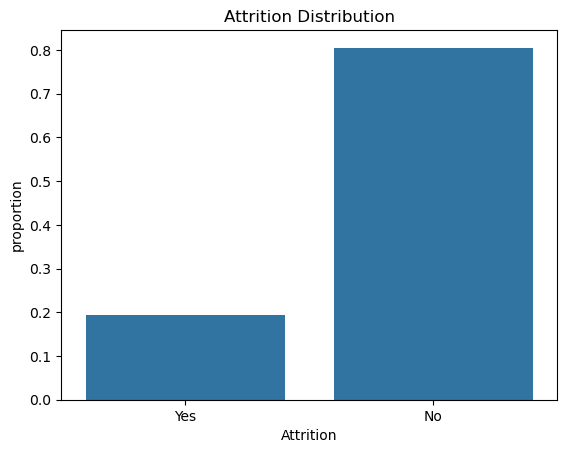

In [31]:
sns.countplot(data=df_combined, x="Attrition", stat="proportion")
plt.title("Attrition Distribution")
plt.show()

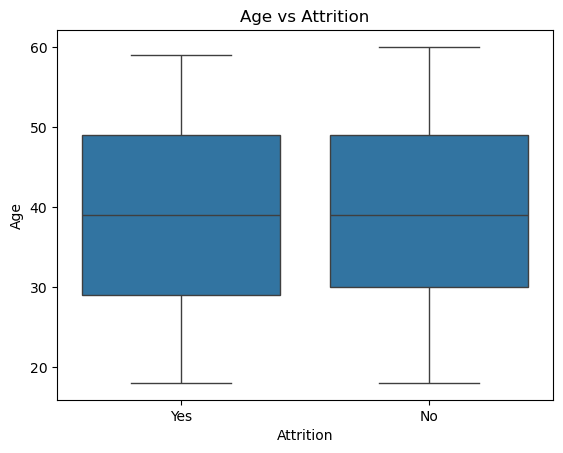

In [27]:
sns.boxplot(data=df_combined, x="Attrition", y="Age")
plt.title("Age vs Attrition")
plt.show()

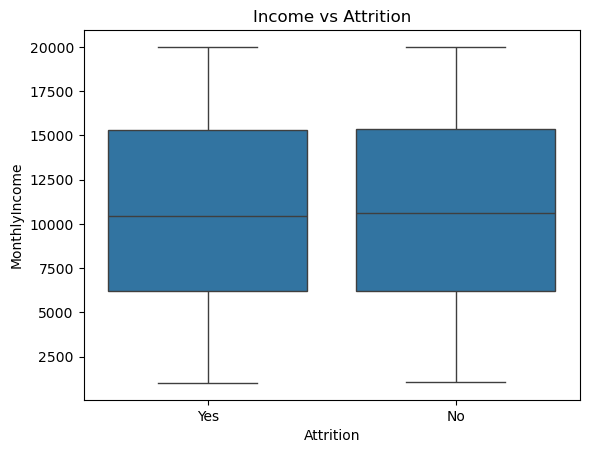

In [28]:
sns.boxplot(data=df_combined, x="Attrition", y="MonthlyIncome")
plt.title("Income vs Attrition")
plt.show()

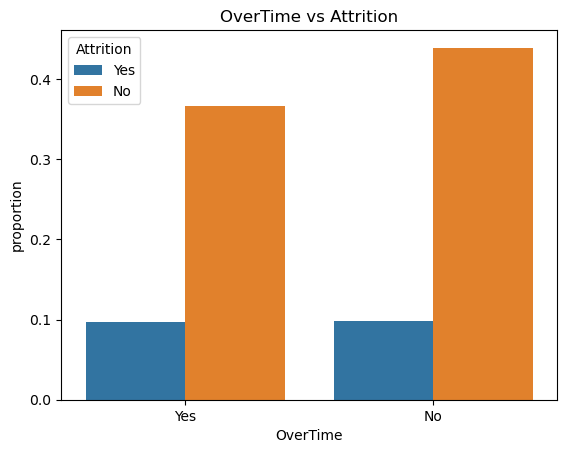

In [32]:
sns.countplot(data=df_combined, x="OverTime", hue="Attrition", stat="proportion")
plt.title("OverTime vs Attrition")
plt.show()

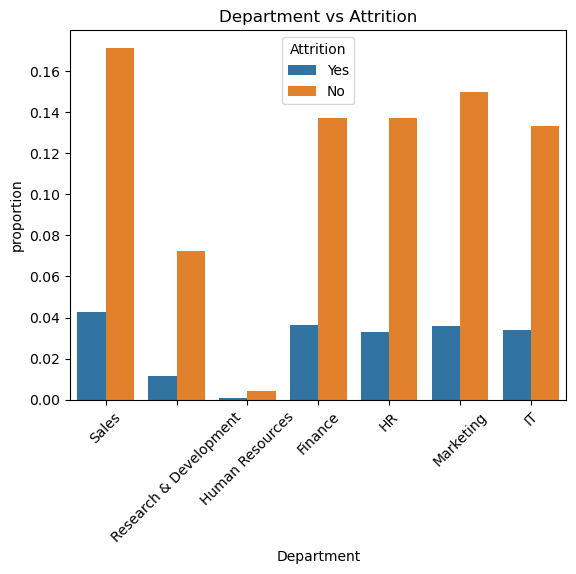

In [33]:
sns.countplot(data=df_combined, x="Department", hue="Attrition", stat="proportion")
plt.xticks(rotation=45)
plt.title("Department vs Attrition")
plt.show()

### Correlation Matrix

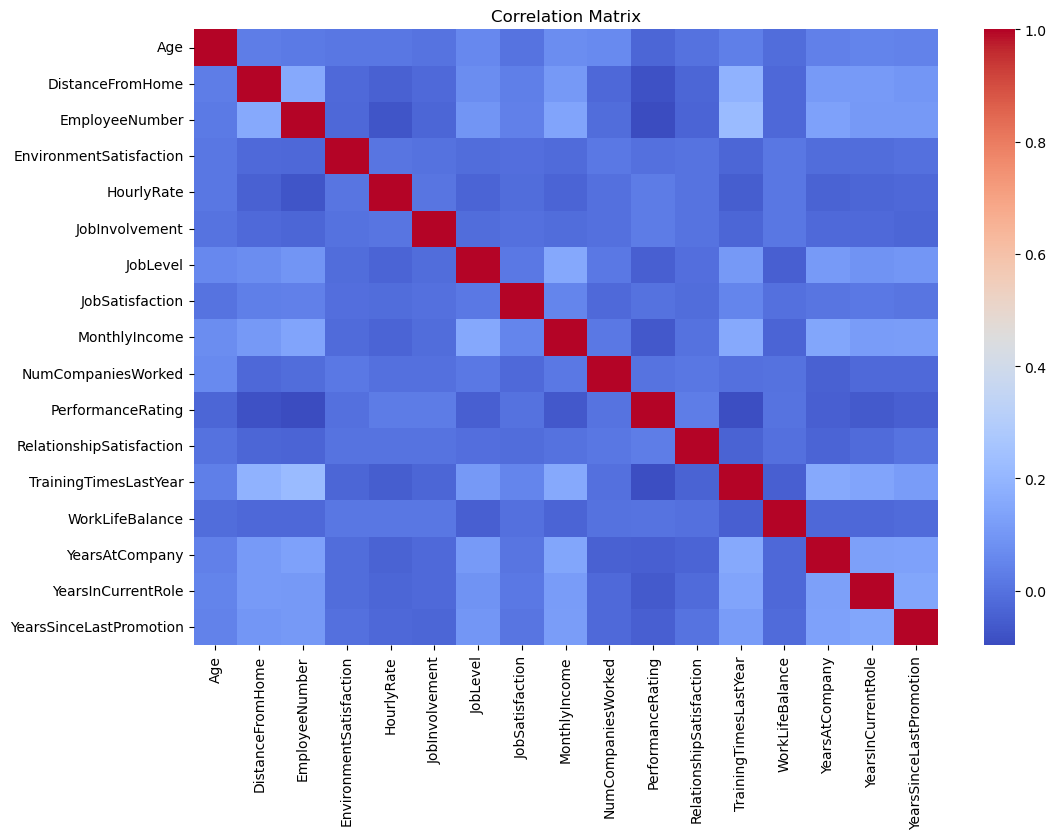

In [34]:
plt.figure(figsize=(12,8))
sns.heatmap(df_combined.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Numerical Feature Distributions

We examine the distribution of key numerical features to detect skewness, outliers, and scale differences that may require transformation (e.g., log transform, standardization) before training.

In [16]:
# Select numerical columns (exclude IDs and constant columns)
num_cols = df_combined.select_dtypes(include='number').columns.tolist()
# Drop ID, binary target, and constant columns
exclude = ['Attrition_Binary', 'EmployeeCount', 'StandardHours', 'Over18', 'Employee_ID']
num_cols = [c for c in num_cols if c not in exclude]

print(f'Numerical features to examine: {len(num_cols)}')
print(num_cols)

Numerical features to examine: 17
['Age', 'DistanceFromHome', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'PerformanceRating', 'RelationshipSatisfaction', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion']


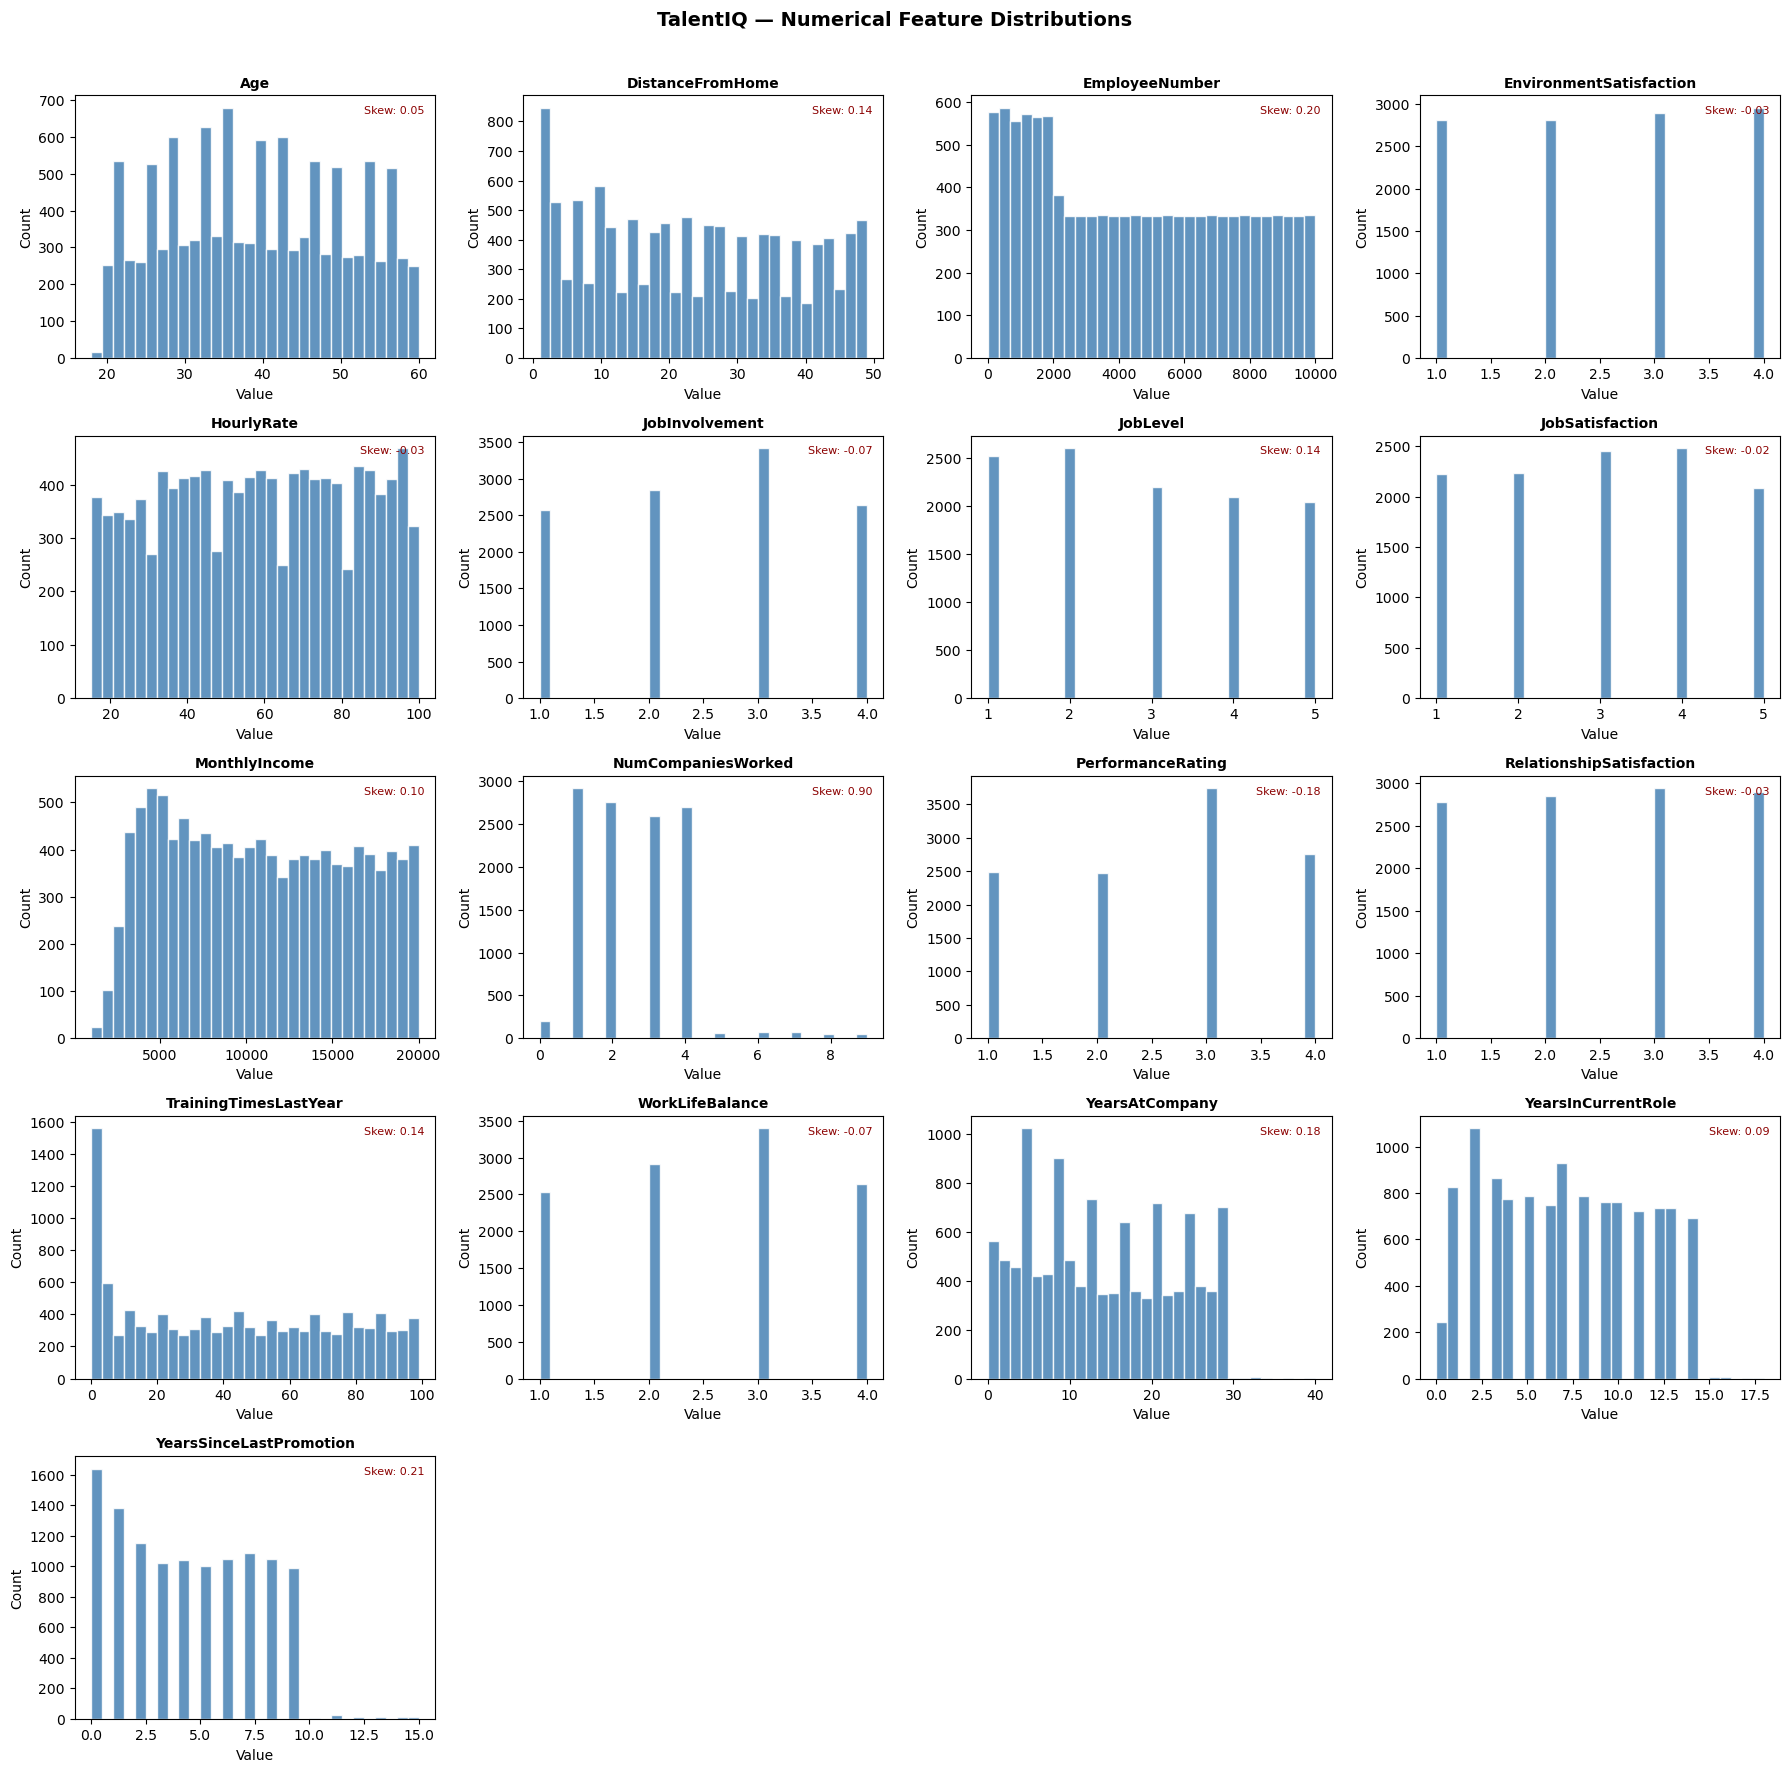

In [19]:
# Histograms for all numerical features
n_cols = 4
n_rows = -(-len(num_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_combined[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    skew = df_combined[col].skew()
    axes[i].annotate(f'Skew: {skew:.2f}', xy=(0.97, 0.93), xycoords='axes fraction',
                     ha='right', fontsize=8, color='darkred')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('TalentIQ — Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/num_distributions.png', bbox_inches='tight')
plt.show()

In [21]:
# Standardize Attrition column to binary 0/1 if needed
if df_combined['Attrition'].dtype == object:
    df_combined['Attrition_Binary'] = df_combined['Attrition'].str.strip().map({'Yes': 1, 'No': 0})
else:
    df_combined['Attrition_Binary'] = df_combined['Attrition']

attrition_counts = df_combined['Attrition_Binary'].value_counts()
attrition_pct    = df_combined['Attrition_Binary'].value_counts(normalize=True) * 100

print('=== Attrition Class Distribution ===')
summary = pd.DataFrame({'Count': attrition_counts, 'Percentage (%)': attrition_pct.round(2)})
summary.index = ['No Attrition (0)', 'Attrition (1)']
print(summary)

imbalance_ratio = attrition_counts[0] / attrition_counts[1]
print(f'\nImbalance ratio: {imbalance_ratio:.2f}:1  (No:Yes)')

=== Attrition Class Distribution ===
                  Count  Percentage (%)
No Attrition (0)   9236           80.52
Attrition (1)      2234           19.48

Imbalance ratio: 4.13:1  (No:Yes)


/tmp/ipykernel_400/749725766.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([no_attr, yes_attr], labels=['No', 'Yes'],
/tmp/ipykernel_400/749725766.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([no_attr, yes_attr], labels=['No', 'Yes'],
/tmp/ipykernel_400/749725766.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([no_attr, yes_attr], labels=['No', 'Yes'],
/tmp/ipykernel_400/749725766.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.1

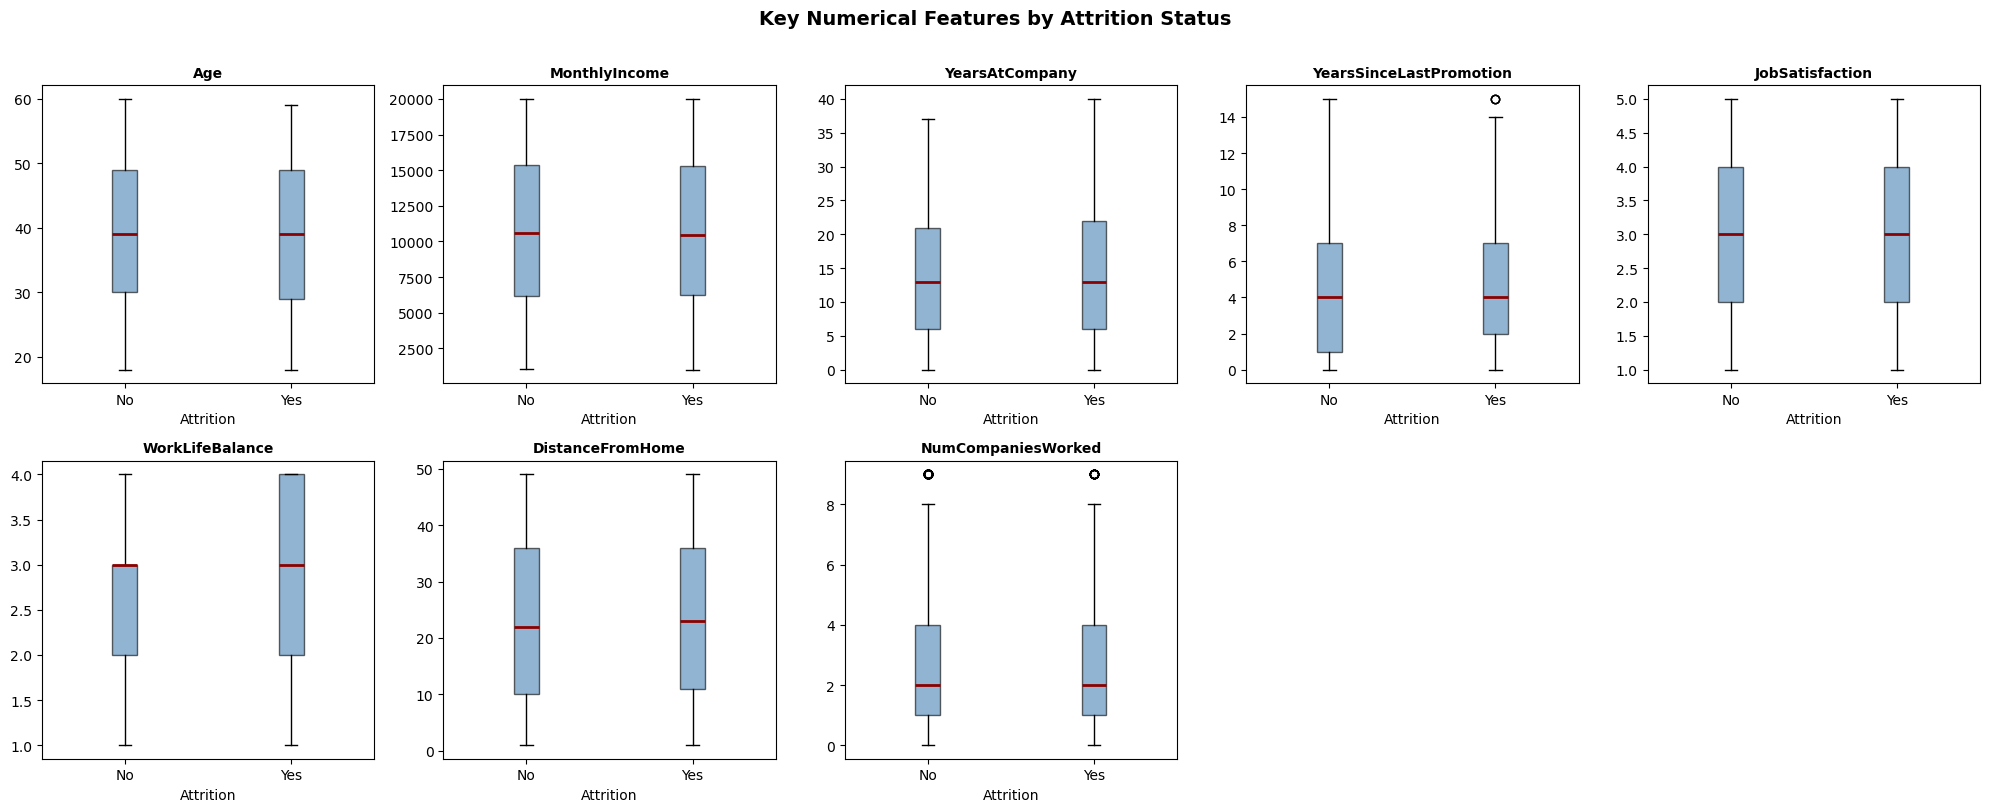

In [23]:
# Box plots split by Attrition — highlight which features differ between groups
key_num_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
                    'YearsSinceLastPromotion', 'JobSatisfaction', 'WorkLifeBalance',
                    'DistanceFromHome', 'NumCompaniesWorked']

# Keep only columns that exist in the dataframe
key_num_features = [c for c in key_num_features if c in df_combined.columns]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(key_num_features):
    no_attr  = df_combined[df_combined['Attrition_Binary'] == 0][col].dropna()
    yes_attr = df_combined[df_combined['Attrition_Binary'] == 1][col].dropna()
    axes[i].boxplot([no_attr, yes_attr], labels=['No', 'Yes'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='darkred', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Attrition')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Key Numerical Features by Attrition Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/boxplots_by_attrition.png', bbox_inches='tight')
plt.show()

## Categorical Feature Analysis

We examine attrition rates across categorical fields to identify high-risk groups and evaluate encoding strategies.

In [27]:
cat_cols = df_combined.select_dtypes(include='object').columns.tolist()
# Exclude the raw Attrition label if it's a string
cat_cols = [c for c in cat_cols if c.lower() != 'attrition']

print(f'Categorical columns: {cat_cols}')
for col in cat_cols:
    print(f'  {col}: {df_combined[col].nunique()} unique values → {df_combined[col].unique()[:8]}')

Categorical columns: ['Department', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
  Department: 7 unique values → ['Sales' 'Research & Development' 'Human Resources' 'Finance' 'HR'
 'Marketing' 'IT']
  Gender: 2 unique values → ['Female' 'Male']
  JobRole: 12 unique values → ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director']
  MaritalStatus: 3 unique values → ['Single' 'Married' 'Divorced']
  OverTime: 2 unique values → ['Yes' 'No']


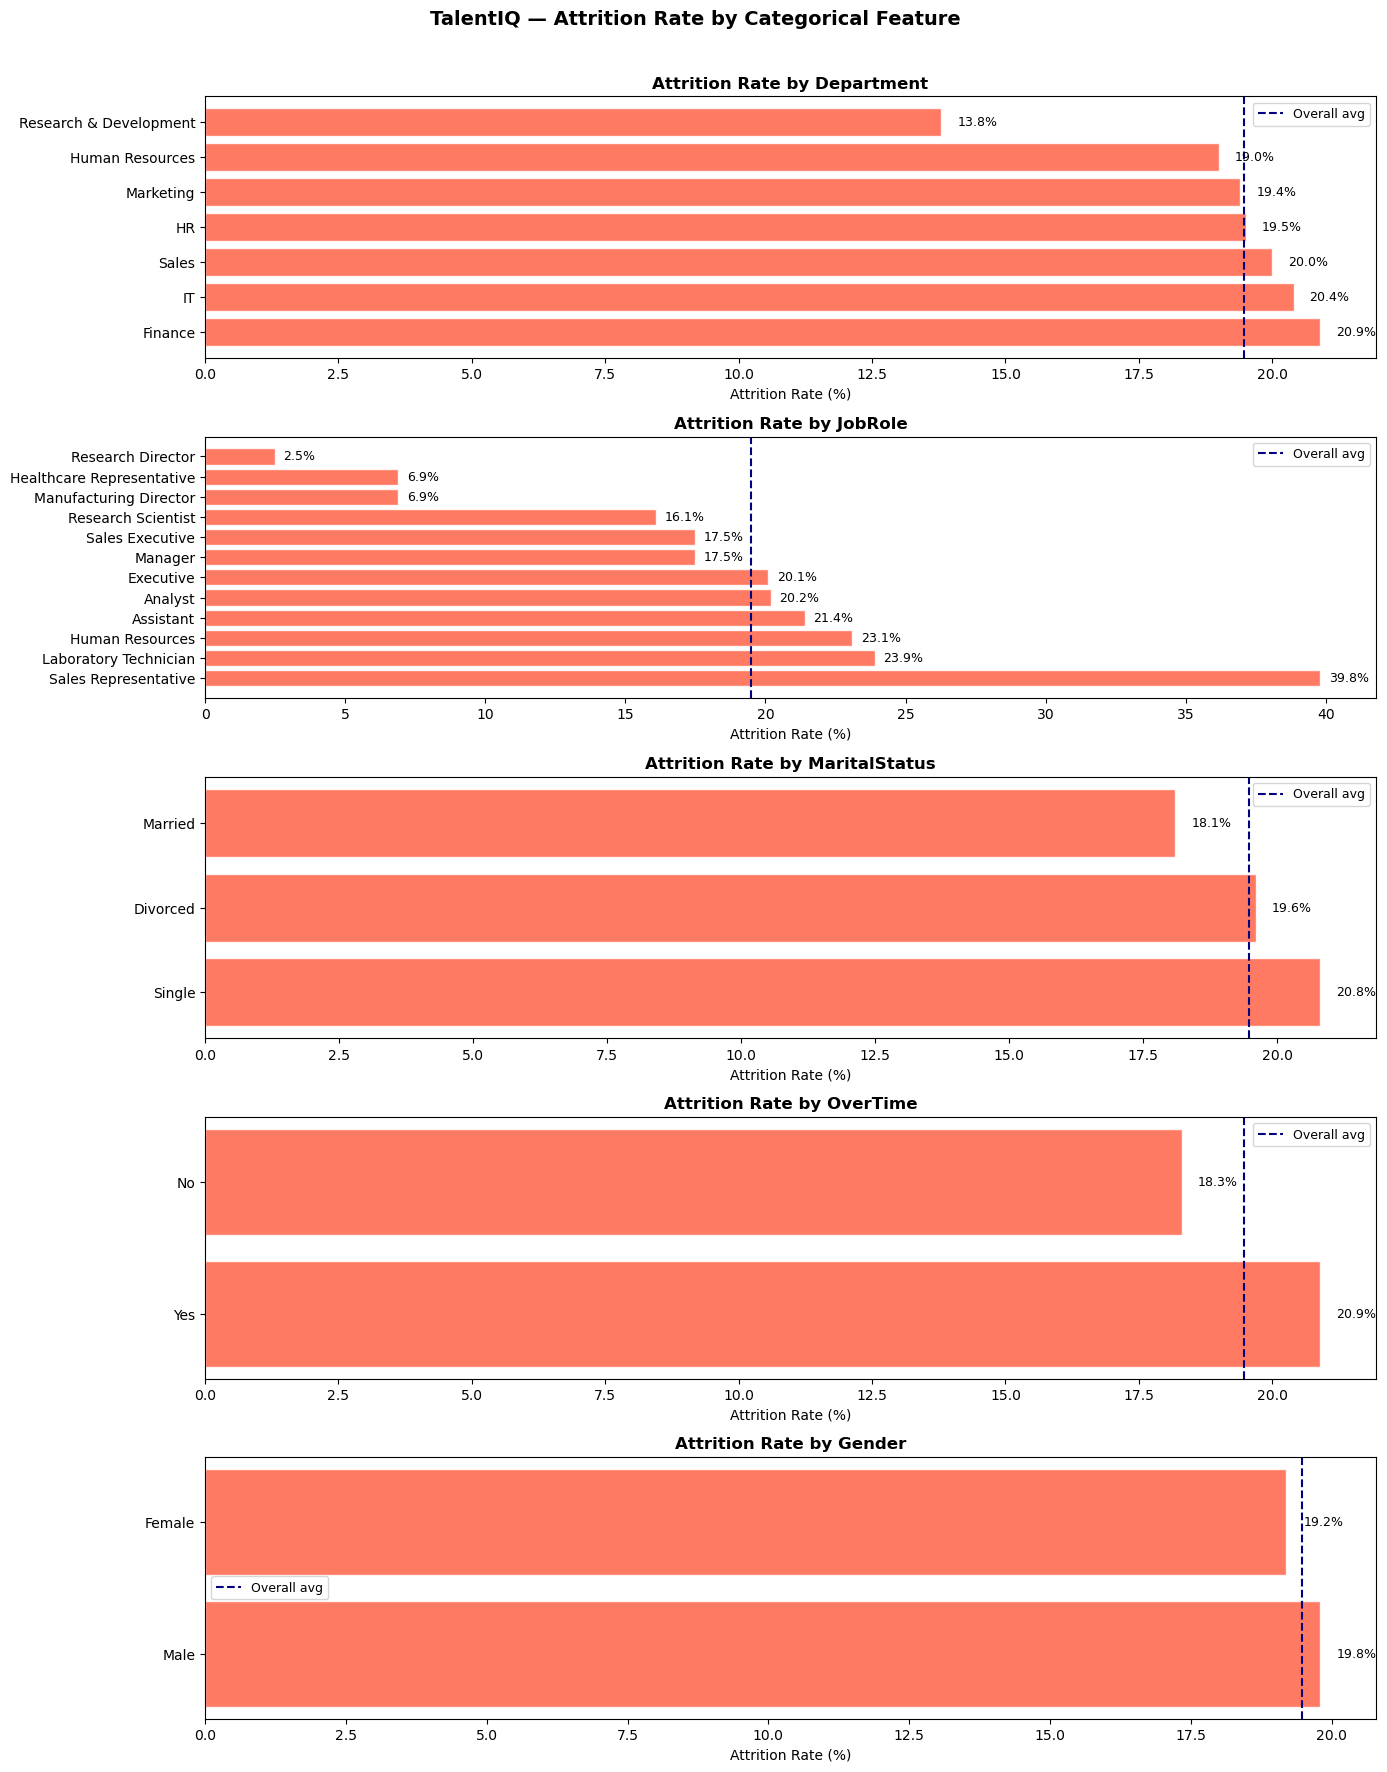

In [28]:
# Attrition rate by key categorical features
key_cat = [c for c in ['Department', 'JobRole', 'EducationField',
                        'MaritalStatus', 'BusinessTravel', 'OverTime', 'Gender']
           if c in df_combined.columns]

fig, axes = plt.subplots(len(key_cat), 1, figsize=(14, len(key_cat) * 3.5))
if len(key_cat) == 1:
    axes = [axes]

for ax, col in zip(axes, key_cat):
    attrition_rate = (
        df_combined.groupby(col)['Attrition_Binary']
          .mean()
          .sort_values(ascending=False)
          .mul(100)
          .round(1)
    )
    bars = ax.barh(attrition_rate.index, attrition_rate.values,
                   color='tomato', edgecolor='white', alpha=0.85)
    ax.axvline(x=df_combined['Attrition_Binary'].mean() * 100, color='navy',
               linestyle='--', linewidth=1.5, label='Overall avg')
    ax.set_xlabel('Attrition Rate (%)')
    ax.set_title(f'Attrition Rate by {col}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, attrition_rate.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val}%', va='center', fontsize=9)

plt.suptitle('TalentIQ — Attrition Rate by Categorical Feature', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/cat_attrition_rates.png', bbox_inches='tight')
plt.show()

### Clean and Merge with Linkedin Job Postings Data

In [24]:
# Convert salary columns
for col in ["min_salary", "max_salary"]:
    if col in df_job_postings.columns:
        df_job_postings[col] = pd.to_numeric(df_job_postings[col], errors="coerce")

# Create avg salary
df_job_postings["external_avg_salary"] = df_job_postings[["min_salary", "max_salary"]].mean(axis=1)

# Remote flag
df_job_postings["remote_flag"] = (
    df_job_postings["remote_allowed"]
    .astype(str)
    .str.lower()
    .isin(["1", "true", "yes"])
    .astype(int)
)

In [25]:
def map_linkedin_role(title):
    title = str(title).lower()

    if "sales executive" in title or "account executive" in title:
        return "Sales Executive"
    elif "research scientist" in title or "scientist" in title:
        return "Research Scientist"
    elif "laboratory technician" in title or "lab technician" in title:
        return "Laboratory Technician"
    elif "human resources" in title or "hr" in title:
        return "Human Resources"
    elif "manager" in title:
        return "Manager"
    else:
        return "Other"

df_job_postings["JobRoleMapped"] = df_job_postings["title"].apply(map_linkedin_role)

In [26]:
# Skill flags
df_job_postings["python_skill"] = df_job_postings["skills_desc"].astype(str).str.contains("python", case=False, na=False).astype(int)
df_job_postings["sql_skill"] = df_job_postings["skills_desc"].astype(str).str.contains("sql", case=False, na=False).astype(int)

# Aggregate by role
linkedin_features = df_job_postings.groupby("JobRoleMapped").agg({
    "external_avg_salary": "mean",
    "remote_flag": "mean",
    "python_skill": "mean",
    "sql_skill": "mean",
    "title": "count"
}).rename(columns={
    "title": "external_job_demand"
}).reset_index()

print(linkedin_features)

           JobRoleMapped  external_avg_salary  remote_flag  python_skill  \
0        Human Resources         61845.109845          0.0           0.0   
1  Laboratory Technician         17372.834231          0.0           0.0   
2                Manager        102997.714045          0.0           0.0   
3                  Other         69047.728947          0.0           0.0   
4     Research Scientist         89817.885930          0.0           0.0   
5        Sales Executive         91683.754386          0.0           0.0   

   sql_skill  external_job_demand  
0   0.000000                  269  
1   0.000000                   33  
2   0.000000                 2542  
3   0.000313                12784  
4   0.000000                  119  
5   0.000000                  139  


In [28]:
def map_hr_role(role):
    role = str(role).lower()

    if "sales executive" in role:
        return "Sales Executive"
    elif "research scientist" in role:
        return "Research Scientist"
    elif "laboratory technician" in role:
        return "Laboratory Technician"
    elif "human resources" in role:
        return "Human Resources"
    elif "manager" in role:
        return "Manager"
    else:
        return "Other"

df_combined["JobRoleMapped"] = df_combined["JobRole"].apply(map_hr_role)

In [29]:
df_combined = df_combined.merge(
    linkedin_features,
    on="JobRoleMapped",
    how="left"
)

# Fill missing values
for col in ["external_avg_salary", "remote_flag", "python_skill", "sql_skill", "external_job_demand"]:
    df_combined[col] = df_combined[col].fillna(0)

# Create salary gap feature
df_combined["salary_gap"] = df_combined["external_avg_salary"] - df_combined["MonthlyIncome"]

print(df_combined.head())
print(df_combined.shape)

   Age Attrition              Department  DistanceFromHome  EmployeeNumber  \
0   41       Yes                   Sales                 1               1   
1   49        No  Research & Development                 8               2   
2   37       Yes  Research & Development                 2               4   
3   33        No  Research & Development                 3               5   
4   27        No  Research & Development                 2               7   

   EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel  ...  \
0                        2  Female          94               3         2  ...   
1                        3    Male          61               2         2  ...   
2                        4    Male          92               2         1  ...   
3                        4  Female          56               3         1  ...   
4                        1    Male          40               3         1  ...   

  YearsAtCompany  YearsInCurrentRole YearsSi

In [32]:
del df_combined['remote_flag']
del df_combined['python_skill']
del df_combined['sql_skill']

In [33]:
bucket = "ads508-team-4-private"

output_path = f"s3://{bucket}/processed/combined_attrition_linkedin_data.csv"

df_combined.to_csv(output_path, index=False)

In [34]:
!aws s3 ls s3://ads508-team-4-private/processed/

2026-04-11 18:50:09     956385 combined_attrition_data.csv
2026-04-11 19:00:25    1496484 combined_attrition_linkedin_data.csv
2026-03-23 03:00:25     224732 test_attrition_data.csv
2026-03-23 03:00:25    1792104 train_attrition_original.csv
2026-03-23 03:00:25    2900902 train_attrition_smote.csv
2026-03-23 03:00:25     224824 validation_attrition_data.csv
